# Clustering y Reducción de Dimensionalidad

**Caso de Estudio:** Ecommerce Customer Dataset
**Asignatura:** MLY1101 — Machine Learning
**Actividad 2.3.2 — Guía de Clustering y Reducción de Dimensionalidad**

---

## Descripción

Las campañas masivas genéricas ya no son rentables: el banco necesita personalizar sus planes de
fidelización. El objetivo de este notebook es **agrupar a los clientes según su comportamiento
financiero**, sin usar ninguna etiqueta previa (aprendizaje no supervisado), para descubrir
segmentos que permitan diseñar campañas específicas y éticas.

Sigue los cuatro pasos de la guía:

1. Carga de datos y preparación (selección de variables y escalado).
2. Elección del número de clústeres con el método del codo.
3. Entrenamiento de K-Means y visualización de los grupos con PCA.
4. Interpretación del perfil de negocio de cada clúster.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Bibliotecas necesarias:

- pandas (>=1.1.0)
- numpy (>=2.0.0)
- matplotlib (>=3.7.1)
- scikit-learn (>=1.3)

# Importación de librerías

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('bmh')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Advertencia espuria de numpy con la librería de cálculo de macOS; no afecta los resultados.
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)

os.makedirs('../images', exist_ok=True)
SEMILLA = 42

# Paso 1 — Carga de datos y preparación

Se seleccionan **solo las variables numéricas que definen el perfil comercial** del cliente:

- **Incluidas:** CreditScore, Age, Tenure, Balance, NumOfProducts y EstimatedSalary.
- **Excluidas:**
  - RowNumber, CustomerId y Surname: identificadores, no describen al cliente.
  - Geography y Gender: son categorías, no medidas numéricas. K-Means agrupa por distancia, y
    una distancia entre "Francia" y "España" no tiene sentido.
  - HasCrCard e IsActiveMember: binarias (0/1). Con solo dos valores posibles dominarían la
    distancia y partirían a los clientes en "sí/no" en vez de por su perfil.
  - Exited: es el resultado que se quiere entender, no una característica del perfil. Se usa
    después, en el Paso 4, para ver cuánto abandona cada grupo.

In [2]:
df = pd.read_csv('../data/ecommerce_customer_data.csv')

variables_perfil = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
X = df[variables_perfil]
X.describe().round(1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,650.5,38.9,5.0,76485.9,1.5,100090.2
std,96.7,10.5,2.9,62397.4,0.6,57510.5
min,350.0,18.0,0.0,0.0,1.0,11.6
25%,584.0,32.0,3.0,0.0,1.0,51002.1
50%,652.0,37.0,5.0,97198.5,1.0,100193.9
75%,718.0,44.0,7.0,127644.2,2.0,149388.2
max,850.0,92.0,10.0,250898.1,4.0,199992.5


Las escalas son muy distintas: Balance llega a 250.898 y EstimatedSalary a casi 200.000, mientras
que NumOfProducts va de 1 a 4. K-Means agrupa por distancia, así que sin escalar, una diferencia
de 1.000 en el saldo pesaría mucho más que tener 3 productos en vez de 1. Por eso se aplica
**StandardScaler**, que deja cada variable con media 0 y desviación 1: todas pesan lo mismo.

In [3]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

pd.DataFrame(X_escalado, columns=variables_perfil).describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,-0.00,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.11,-1.99,-1.73,-1.23,-0.91,-1.74
25%,-0.69,-0.66,-0.70,-1.23,-0.91,-0.85
50%,0.02,-0.18,-0.00,0.33,-0.91,0.00
75%,0.70,0.48,0.69,0.82,0.81,0.86
max,2.06,5.06,1.72,2.80,4.25,1.74


# Paso 2 — Número óptimo de clústeres (método del codo)

Se entrena K-Means con K = 1 hasta K = 10 y se guarda la **inercia** de cada uno: la suma de las
distancias al cuadrado de cada cliente al centro de su grupo. Mientras más grupos, menor la
inercia (con 10.000 grupos sería 0), así que no se busca el mínimo, sino el **codo**: el punto a
partir del cual agregar un grupo más ya casi no la reduce.

Como complemento se calcula el **coeficiente de Silhouette** (desde K = 2), que mide qué tan
separados están los grupos entre sí: va de -1 a 1, y mientras más alto, más claros son los grupos.

In [4]:
rango_k = range(1, 11)
inercias = []
silhouettes = []
for k in rango_k:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X_escalado)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_escalado, kmeans.labels_) if k > 1 else np.nan)

resultados_k = pd.DataFrame({'inercia': inercias, 'silhouette': silhouettes}, index=rango_k)
resultados_k['reduccion_inercia'] = -resultados_k['inercia'].diff()
resultados_k.round(3)

,inercia,silhouette,reduccion_inercia
1,60000.000,NaN,NaN
2,49855.569,0.179,10144.431
3,45127.165,0.147,4728.404
4,41152.408,0.150,3974.757
5,38153.149,0.158,2999.260
6,35715.116,0.150,2438.033
7,33722.251,0.148,1992.865
8,32120.139,0.146,1602.112
9,30627.350,0.146,1492.788
10,29309.381,0.150,1317.969


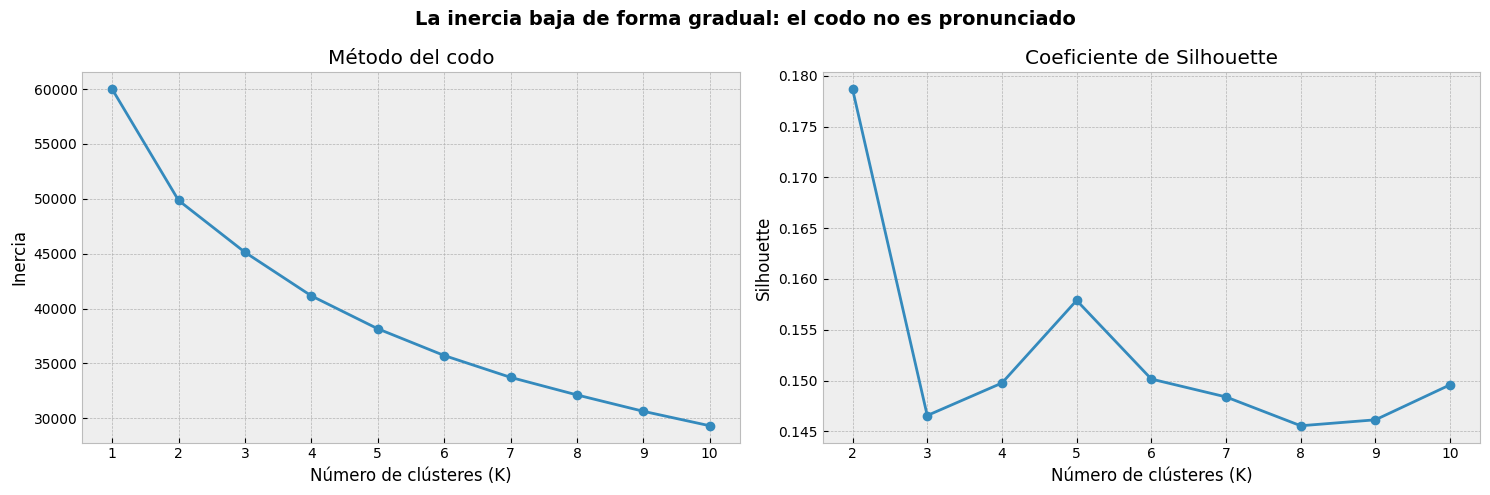

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(list(rango_k), inercias, marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('Número de clústeres (K)')
axes[0].set_ylabel('Inercia')
axes[0].set_xticks(list(rango_k))

axes[1].plot(list(rango_k)[1:], silhouettes[1:], marker='o')
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('Número de clústeres (K)')
axes[1].set_ylabel('Silhouette')
axes[1].set_xticks(list(rango_k)[1:])

plt.suptitle('La inercia baja de forma gradual: el codo no es pronunciado', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/clustering_codo.png', dpi=150, bbox_inches='tight')
plt.show()

**Pregunta: ¿en qué valor de K se aprecia el codo? Justifica la elección.**

La inercia no muestra un codo marcado, sino una curva que baja de forma gradual. La mayor caída
está al pasar de K = 1 a K = 2 (-10.144); después la reducción se va achicando poco a poco
(-4.728 al pasar a K = 3, -3.975 a K = 4, -2.999 a K = 5, y menos de -2.500 desde ahí). Visualmente,
la curvatura se suaviza entre **K = 3 y K = 4**: a partir de K = 4, cada grupo adicional reduce la
inercia bastante menos.

Se elige **K = 4**, por tres razones:

- **Codo:** es el último valor antes de que la reducción de inercia baje de ~4.000 a ~3.000 y siga
  achicándose.
- **Silhouette:** K = 2 tiene el valor más alto (0,179), pero solo separa a los clientes con y sin
  saldo, algo que ya se sabía desde el EDA. Entre K = 3 y K = 10 los valores son muy parecidos
  (0,146 a 0,158), así que el Silhouette no favorece claramente a ningún K mayor que 2.
- **Utilidad para el negocio:** con K = 4 aparece un grupo de clientes mayores con alto abandono
  que K = 2 y K = 3 no separan, y que es justamente el tipo de segmento que sirve para una
  campaña de fidelización.

**Advertencia:** todos los Silhouette son bajos (menores a 0,2). Los clientes no forman grupos
naturales muy separados, sino un continuo; los clústeres son una forma útil de dividirlo en
segmentos, no grupos "reales" con límites claros.

# Paso 3 — Entrenamiento final de K-Means y visualización con PCA

In [6]:
K_OPTIMO = 4

kmeans = KMeans(n_clusters=K_OPTIMO, n_init=10, random_state=SEMILLA)
df['cluster'] = kmeans.fit_predict(X_escalado)

df['cluster'].value_counts().sort_index()

cluster
0    1390
1    2673
2    3084
3    2853
Name: count, dtype: int64

Para ver los grupos en un gráfico hay que pasar de 6 dimensiones (una por variable) a 2. **PCA**
(Análisis de Componentes Principales) crea dos nuevas variables, combinaciones de las originales,
que conservan la mayor cantidad posible de la variación de los datos.

Varianza explicada por cada componente: [0.219 0.169]
Varianza explicada total: 0.387


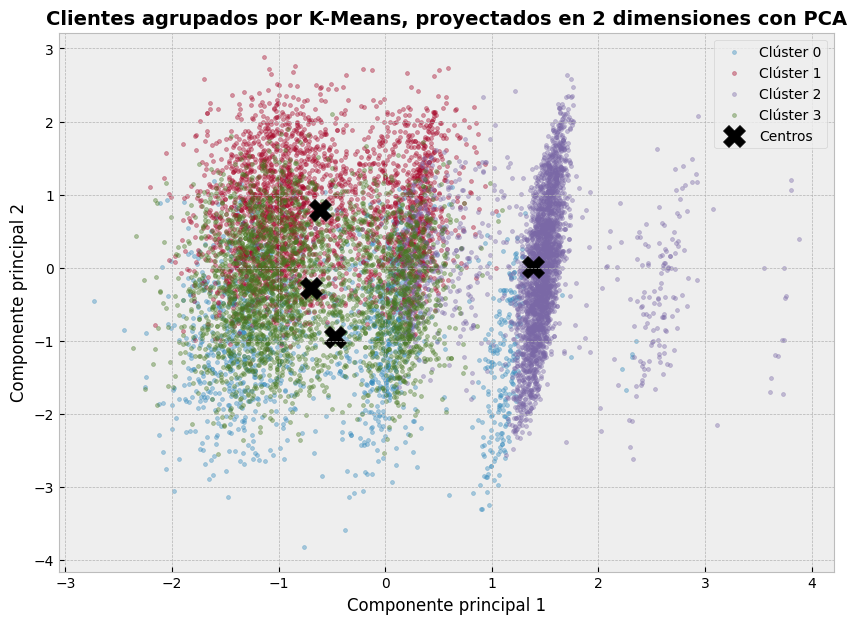

In [7]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_escalado)
centros_pca = pca.transform(kmeans.cluster_centers_)

print(f'Varianza explicada por cada componente: {np.round(pca.explained_variance_ratio_, 3)}')
print(f'Varianza explicada total: {pca.explained_variance_ratio_.sum():.3f}')

plt.figure(figsize=(10, 7))
for cluster in range(K_OPTIMO):
    mascara = df['cluster'] == cluster
    plt.scatter(componentes[mascara, 0], componentes[mascara, 1], s=8, alpha=0.4, label=f'Clúster {cluster}')
plt.scatter(centros_pca[:, 0], centros_pca[:, 1], s=250, c='black', marker='X', label='Centros')
plt.title('Clientes agrupados por K-Means, proyectados en 2 dimensiones con PCA', fontsize=14, fontweight='bold')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend()
plt.savefig('../images/clustering_pca.png', dpi=150, bbox_inches='tight')
plt.show()

Las dos componentes conservan el 38,7% de la variación de los datos (21,9% + 16,9%): el mapa es
una simplificación y es normal que los grupos se vean superpuestos en él.

- El **clúster de clientes sin saldo** queda claramente separado a la derecha: el saldo es la
  variable que más distingue a los clientes.
- Los otros tres clústeres se superponen en la zona izquierda. Se diferencian por variables como
  la edad o la antigüedad, que en estas dos dimensiones no se ven completas.

Esto es coherente con el Silhouette bajo del Paso 2.

# Paso 4 — Interpretación del perfil de negocio

Se calcula el promedio de las variables originales (sin escalar) en cada clúster. Se agregan
tres columnas que no se usaron para agrupar, pero ayudan a describir cada grupo: el % de clientes
con saldo 0, el % de abandono (Exited) y el % de clientes activos.

In [8]:
perfil = df.groupby('cluster')[variables_perfil].mean()
perfil['pct_saldo_cero'] = df.groupby('cluster')['Balance'].apply(lambda s: (s == 0).mean() * 100)
perfil['pct_abandono'] = df.groupby('cluster')['Exited'].mean() * 100
perfil['pct_activos'] = df.groupby('cluster')['IsActiveMember'].mean() * 100
perfil['clientes'] = df['cluster'].value_counts()

# Nombre de cada clúster según su rasgo principal (así no depende del número que le asigne K-Means)
nombres = {}
nombres[perfil['Age'].idxmax()] = 'Senior'
nombres[perfil['pct_saldo_cero'].idxmax()] = 'Sin saldo'
restantes = perfil.drop(index=list(nombres)).sort_values('Tenure')
nombres[restantes.index[0]] = 'Nuevos con saldo'
nombres[restantes.index[1]] = 'Antiguos con saldo'

perfil.index = [f'{c} - {nombres[c]}' for c in perfil.index]
perfil.round(1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,pct_saldo_cero,pct_abandono,pct_activos,clientes
0 - Senior,644.4,58.0,4.8,78417.2,1.4,95406.8,32.9,45.0,62.9,1390
1 - Antiguos con saldo,644.9,36.1,7.8,111720.8,1.3,102528.3,8.6,19.3,47.5,2673
2 - Sin saldo,650.2,35.9,5.1,10867.3,2.0,99602.0,88.3,12.1,49.5,3084
3 - Nuevos con saldo,659.1,35.6,2.4,113464.5,1.3,100615.6,7.2,18.4,51.8,2853


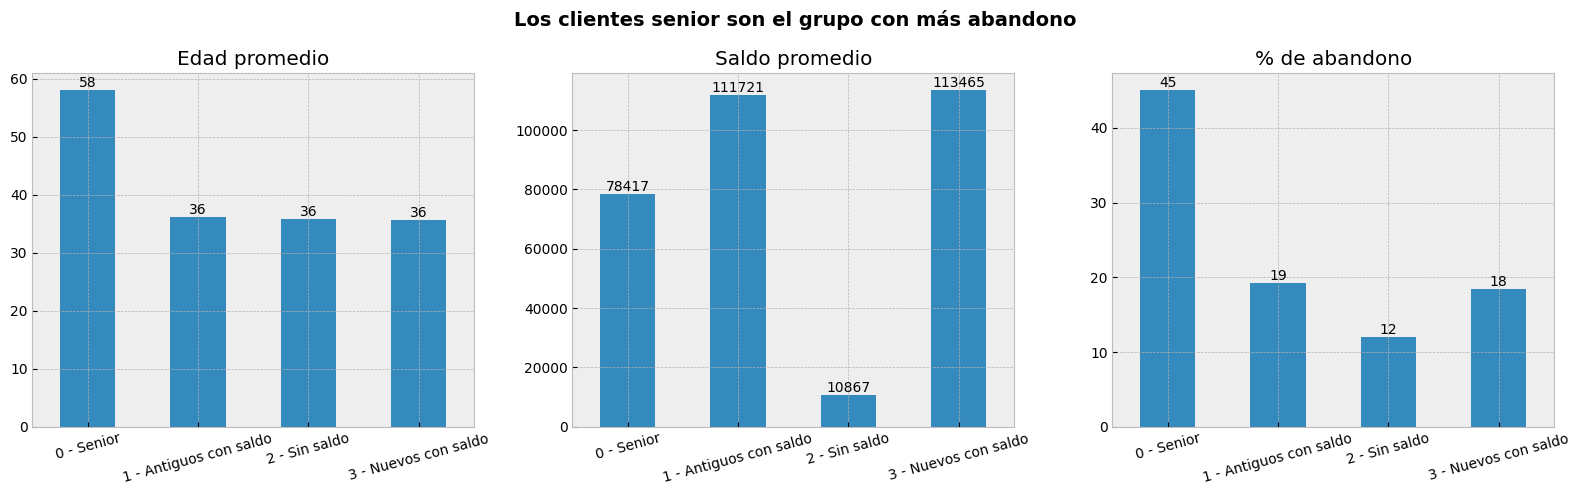

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (columna, titulo) in zip(axes, [('Age', 'Edad promedio'), ('Balance', 'Saldo promedio'),
                                          ('pct_abandono', '% de abandono')]):
    perfil[columna].plot(kind='bar', ax=ax, rot=15)
    ax.bar_label(ax.containers[0], fmt='%.0f')
    ax.set_title(titulo)
plt.suptitle('Los clientes senior son el grupo con más abandono', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/clustering_perfiles.png', dpi=150, bbox_inches='tight')
plt.show()

**Identidad de los clústeres descubiertos:**

| Clúster | Perfil | Rasgos principales |
|---|---|---|
| **Senior** (1.390 clientes) | Clientes mayores, con saldo medio | Edad promedio 58 años, saldo medio ~78.400 y 33% sin saldo. Son los más activos (63%), pero tienen el **abandono más alto: 45%**. |
| **Antiguos con saldo** (2.673) | Clientes jóvenes y fieles, con fondos | 36 años, la mayor antigüedad (7,8 años) y saldo alto (~111.700). Abandono de 19%. |
| **Sin saldo** (3.084) | Clientes jóvenes sin fondos, con 2 productos | 36 años, saldo medio ~10.900 (88% con saldo 0) y 2 productos en promedio. El **abandono más bajo: 12%**. |
| **Nuevos con saldo** (2.853) | Clientes jóvenes recién llegados, con fondos | 36 años, la menor antigüedad (2,4 años) y el saldo más alto (~113.500). Abandono de 18%. |

El puntaje crediticio y el salario estimado son casi iguales en los cuatro grupos (~645-660 y
~95.000-103.000): no definen ningún segmento, igual que en el EDA, donde tampoco se relacionaban
con el abandono.

Los segmentos coinciden con los hallazgos del EDA, pero ahora descubiertos sin usar el abandono
para agrupar: la edad y tener o no saldo son lo que más distingue a los clientes.

In [10]:
# Composición por país de cada clúster (% de clientes)
por_pais = pd.crosstab(df['cluster'].map(lambda c: f'{c} - {nombres[c]}'), df['Geography'], normalize='index') * 100
por_pais.round(1)

Geography,France,Germany,Spain
cluster,,,
0 - Senior,46.5,29.1,24.5
1 - Antiguos con saldo,43.4,34.4,22.1
2 - Sin saldo,63.3,5.9,30.8
3 - Nuevos con saldo,44.0,35.2,20.9


Los clústeres no usaron el país para agrupar, pero su composición no es pareja: el grupo **Sin
saldo** tiene solo 5,9% de clientes alemanes, contra ~30-35% en los otros tres. Es consecuencia
directa de que ningún cliente de Alemania tiene saldo 0 en esta muestra, un patrón que
probablemente se debe a cómo se armó la muestra (EDA, Sección 2.7). Hay que tenerlo en cuenta:
una campaña dirigida a los clústeres con saldo alcanzaría proporcionalmente a más alemanes, por
cómo se construyeron los datos y no por una decisión explícita.

# Desafío estratégico

**Si el banco lanzara un producto de inversión de alta gama y bajo riesgo, ¿a qué clúster
enfocarías éticamente la campaña y por qué?**

Al clúster **Antiguos con saldo**:

- **Tienen fondos para invertir:** saldo promedio de ~111.700 y solo 9% de clientes sin saldo. Un
  producto de alta gama requiere capital disponible, y ofrecérselo a quien lo tiene no
  compromete sus necesidades básicas.
- **Relación consolidada con el banco:** la mayor antigüedad (7,8 años) indica confianza mutua y
  un historial que permite ofrecer el producto de forma informada, sin presión.
- **Coherente con el bajo riesgo:** a clientes con fondos estables les conviene diversificar sin
  arriesgar su patrimonio.

**Qué no sería ético:**

- **Clúster Sin saldo:** empujar un producto de inversión a clientes que casi no tienen fondos
  podría llevarlos a endeudarse o a comprometer dinero que necesitan.
- **Clúster Senior como blanco principal:** tienen fondos y un producto de bajo riesgo podría
  convenirles, pero son el grupo con más abandono (45%). La tentación sería usar la inversión
  como "gancho" para retenerlos, y dirigir productos financieros a personas mayores por su edad
  exige especial cuidado para no aprovecharse de ellos. Si se les ofrece, debe ser con asesoría
  transparente y no como campaña agresiva.
- **Clúster Nuevos con saldo:** tiene fondos, pero una relación reciente (2,4 años). Es un buen
  segundo público, con más información y sin presionar la decisión.

Además, la segmentación no usa género ni país, lo que evita que la campaña discrimine
directamente por esas características; aun así, como se vio arriba, la composición por país de
los clústeres está influida por cómo se armó la muestra.

# Resumen

- Se agrupó a los 10.000 clientes con K-Means según seis variables numéricas de su perfil
  comercial, escaladas con StandardScaler para que todas pesen lo mismo.
- El método del codo no mostró un codo marcado; se eligió **K = 4** por la curvatura entre K = 3 y
  K = 4 y por la utilidad de los segmentos para el negocio. El Silhouette bajo (< 0,2) indica que
  los clientes forman un continuo más que grupos naturalmente separados.
- PCA en dos dimensiones conserva el 38,7% de la variación: solo el grupo sin saldo se ve
  claramente separado.
- Los cuatro segmentos son **Senior** (45% de abandono), **Antiguos con saldo**, **Sin saldo**
  (12% de abandono) y **Nuevos con saldo**.
- Para un producto de inversión de alta gama y bajo riesgo, el público éticamente adecuado es
  **Antiguos con saldo**: tienen fondos y una relación consolidada con el banco.